### <u>Exercice :</u> Construction d'un réseau de neurones de classification binaire de points

In [1]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn 
#import torch.optim as optim
import numpy as np 
import torch.nn.functional as F

In [4]:
# 1. Génération des données avec scikit-learn
# n_samples = nombre de points / noise = l'éparpillement des points (plus c'est haut, plus c'est dur)
X_np, y_np = make_moons(n_samples=1000, noise=0.1, random_state=42)
# X_np = tableau à deux colonnes (coordonnées x y), y_np = liste binaire couleur du point

In [ ]:
#print(y_np[:10]) # Affichage des 10 premiers caractères
#len(y_np) # = 1000
#print(X_np[:10,:10]) #Affichage des coordonnées des 10 premiers points
#len(X_np) # = 1000

1000

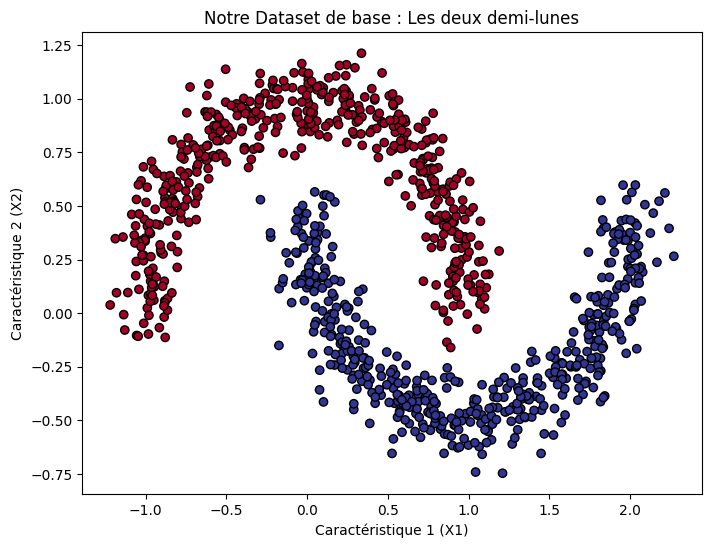

In [3]:
# 2. Affichage des données (Visualisation)
plt.figure(figsize=(8, 6))
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap=plt.cm.RdYlBu, edgecolors='k')
plt.title("Notre Dataset de base : Les deux demi-lunes")
plt.xlabel("Caractéristique 1 (X1)")
plt.ylabel("Caractéristique 2 (X2)")
plt.show()

In [44]:
# 3. Transition vers PyTorch 
# Conversion des tableaux NumPy (générés par sklearn) en Tensors PyTorch.
# On précise torch.float32 pour X car les réseaux de neurones s'entraînent avec des floats.
X = torch.tensor(X_np, dtype=torch.float32)

# On redimensionne y pour qu'il ait la forme (1000, 1) au lieu de (1000,)
# C'est une subtilité de PyTorch qui évite beaucoup de bugs de dimension ("broadcasting")
y = torch.tensor(y_np, dtype=torch.float32).view(-1, 1)

print(f"Forme de X (nos coordonnées) : {X.shape}")
print(f"Forme de y (nos étiquettes / couleurs) : {y.shape}")

Forme de X (nos coordonnées) : torch.Size([1000, 2])
Forme de y (nos étiquettes / couleurs) : torch.Size([1000, 1])


### Structure du Réseau

- Inputs : 2 valeurs -> couple de coordonnées x y
- Outputs : 1 seule valeur -> probabilité (pour rouge ou bleu)

In [ ]:
# 4. Data Split

training_size = 800

X_train = X[:training_size, :]
X_test = X[training_size:, :]

y_train = y[:training_size, :]
y_test = y[training_size:, :]

Batch_size = 40

# Utilisation d'un Data Loader -> Création des Batchs :
dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=Batch_size, shuffle=True)



In [108]:
# 5. Création du réseau de neurones

class Model(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(2,16, bias=False)
        self.bn1 = nn.BatchNorm1d(16, eps=1e-06, momentum=0.1, track_running_stats=True, bias=True)

        self.fc2 = nn.Linear(16,16, bias=False)
        self.bn2 = nn.BatchNorm1d(16, eps=1e-06, momentum=0.1, track_running_stats=True, bias=True)

        self.fc3 = nn.Linear(16,1, bias=True)

    def forward(self, x):

        x = F.relu(self.bn1(self.fc1(x)))

        x = F.relu(self.bn2(self.fc2(x)))

        x = self.fc3(x)

        return x

mlp = Model()

In [110]:
# 5. Création du réseau de neurones

mlp = nn.Sequential(
    
    # Couche 1
    nn.Linear(2, 16, bias=False),
    nn.BatchNorm1d(16, eps=1e-06, momentum=0.1, track_running_stats=True, bias=True),
    nn.ReLU(),
    
    #Couche 2
    nn.Linear(16, 16, bias=False),
    nn.BatchNorm1d(16, eps=1e-06, momentum=0.1, track_running_stats=True, bias=True),
    nn.ReLU(),
    
    #Couche 3
    nn.Linear(16, 1, bias=True)
)

In [ ]:
# 6. Training

criterion = nn.BCEWithLogitsLoss()
#optimizer = optim.Adam(mlp.parameters(), lr=0.01)

lr = 0.1

epochs = 100

update_ratios = []
steps = []
global_step = 0

# Boucle de 100 itérations
for epoch in range(epochs):

    # Boucle de (training_size/Batch_size) itérations
    for X_batch, y_batch in loader:

        # 1. foward pass :
        y_pred = mlp(X_batch)

        # 2. loss :
        loss = criterion(y_pred, y_batch)
        if global_step == 0:
            print(f"Premier loss = {loss.item():.4f}")

        # 3. reset grad :
        #optimizer.zero_grad()
        for p in mlp.parameters():
            p.grad = None

        # 4. back pass :
        loss.backward()

        # 5. update weights
        #optimizer.step()
        with torch.no_grad():
            for p in mlp.parameters():
                if p.grad is not None:
                    p.data -= lr*p.grad

        # 6. Diagnostic Learning Rate lr
        with torch.no_grad():
            derniere_couche = mlp[-1].weight
            update_ratio = torch.log10((lr * derniere_couche.grad.abs().mean()) / derniere_couche.abs().mean())
            update_ratios.append(update_ratio)
            
            global_step += 1 
            steps.append(global_step)

print(f"Dernier loss = {loss.item():.4f}")

Premier loss = 0.6548
Dernier loss = 0.0139


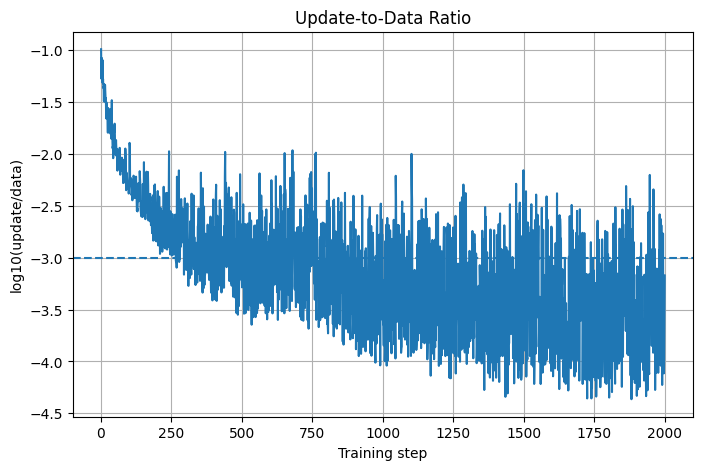

In [112]:
plt.figure(figsize=(8,5))
plt.plot(steps, update_ratios)
plt.axhline(-3, linestyle='--')
plt.xlabel("Training step")
plt.ylabel("log10(update/data)")
plt.title("Update-to-Data Ratio")
plt.grid(True)
plt.show()

In [113]:
# 7. Phase de test

# mlp en mode "évaluation" -> stop au calcul de mean et std par BatchNorm1d / Utilisation : running_mean & running_std
mlp.eval()

with torch.no_grad():
    # foward pass avec toutes les test datas
    y_predt = mlp(X_test)

    # loss
    loss_test = criterion(y_predt, y_test)

    print(f"Test Loss : {loss_test.item():.6f}")

    # Calcul de la précision
    pred_binaire = (y_predt > 0).float()    # Bascule à zéro -> logits
    accuracy = (pred_binaire == y_test).float().mean()
    print(f"Précision sur le Test : {accuracy.item() * 100:.2f} %")


Test Loss : 0.004868
Précision sur le Test : 100.00 %


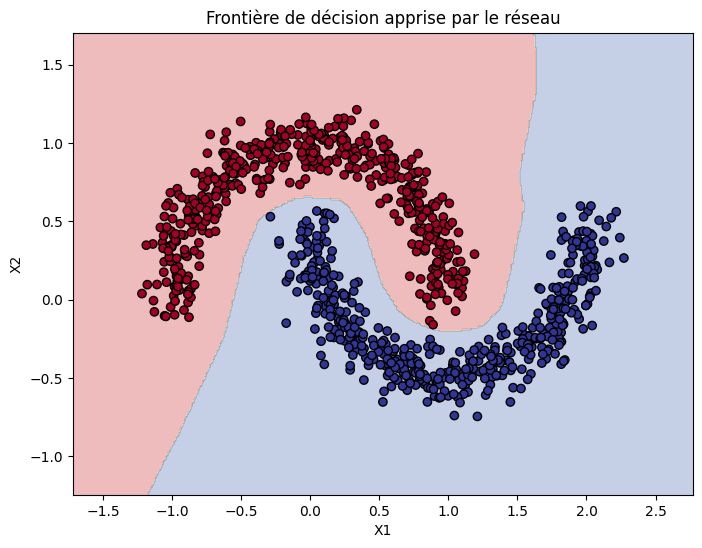

In [114]:
# 8. Tracé final

def tracer_frontiere(modele, X_data, y_data):
    # 1. On passe le modèle en mode évaluation (comme tu as si bien compris !)
    modele.eval()
    
    # 2. On détermine les limites de notre "carte" avec un peu de marge
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5
    
    # 3. On crée une grille (un maillage) de points invisibles très serrés (espacés de 0.01)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    # 4. On transforme ces millions de coordonnées (xx, yy) en un gros Tensor PyTorch
    # ravel() aplatit le tableau 2D en 1D, et c_[] les colle côte à côte (X1, X2)
    grille_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    
    # 5. L'INFERENCE : Le modèle donne son avis sur chaque point de la grille
    with torch.no_grad():
        predictions_logits = modele(grille_points)
        # Comme on l'a vu : si logit > 0 c'est 1 (Rouge), sinon 0 (Bleu)
        predictions = (predictions_logits > 0).float()
        
    # 6. On redonne à nos prédictions la forme de la grille d'origine (pour Matplotlib)
    Z = predictions.numpy().reshape(xx.shape)
    
    # 7. LE DESSIN
    plt.figure(figsize=(8, 6))
    # contourf colorie le fond selon les valeurs de Z (0 ou 1)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    
    # On rajoute par-dessus les VRAIS points de notre dataset pour voir s'ils sont du bon côté
    plt.scatter(X_data[:, 0], X_data[:, 1], c=y_data, cmap=plt.cm.RdYlBu, edgecolors='k')
    plt.title("Frontière de décision apprise par le réseau")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.show()

# --- Lancement de la fonction ---
# Tu peux tester avec tes données de Train ou de Test (assure-toi que X et y sont des Tensors)
tracer_frontiere(mlp, X.numpy(), y.numpy())